In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('spam.csv', encoding_errors='ignore')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

SMS Spam Classifier

Steps:

1. Data cleaning
2. EDA
3. Text Processing
4. Model building
5. Evaluation
6. Improvement
7. Website
8. Deploy

#1. Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [10]:
df.sample(5)

,v1,v2
1111,ham,"Awesome, think we can get an 8th at usf some t..."
308,spam,TheMob> Check out our newest selection of cont...
451,ham,Thanks for this hope you had a good day today
311,spam,Think ur smart ? Win 200 this week in our week...
155,ham,Aaooooright are you at work?


In [13]:
df.rename(columns={'v1' : 'target', 'v2': 'text'}, inplace=True)

In [14]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [18]:
df['target'] = encoder.fit_transform(df['target'])

0 -> ham

1 -> spam

In [19]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df.isnull().sum()

,0
target,0
text,0


In [21]:
df.duplicated().sum()

np.int64(404)

In [23]:
df = df.drop_duplicates(keep='first')

In [25]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
df.duplicated().sum()

np.int64(0)

#2. EDA

In [28]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
df['target'].value_counts()

,count
target,
0,4516
1,652


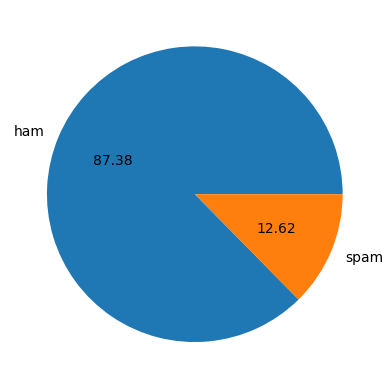

In [31]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

This data is clearly imbalanced

In [32]:
!pip install nltk

In [33]:
import nltk

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [43]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [36]:
df['num_characters'] = df['text'].apply(len)

In [37]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [45]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [46]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [47]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [48]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [49]:
df.describe()

,target,num_characters,num_words,num_sentences
count,5168.000000,5168.000000,5168.000000,5168.000000
mean,0.126161,78.759481,18.441176,1.966331
std,0.332063,58.104099,13.327587,1.449367
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,116.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


<Axes: xlabel='num_characters', ylabel='Count'>

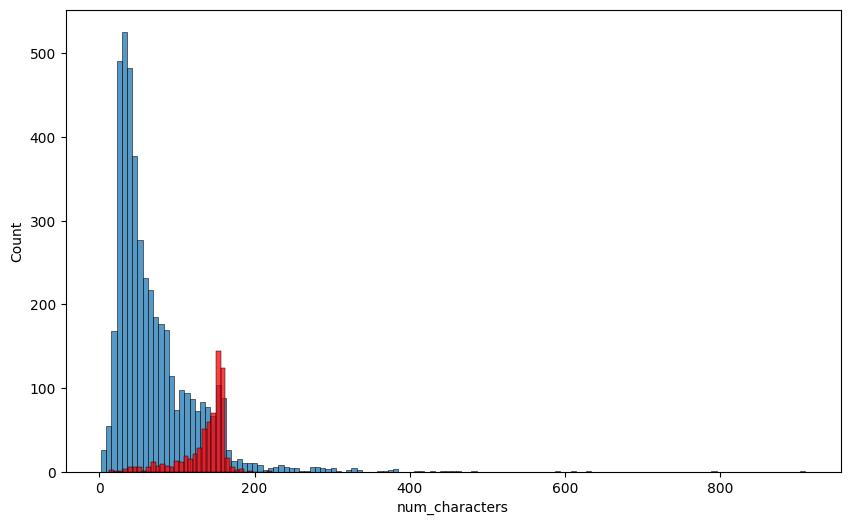

In [52]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color = 'red')

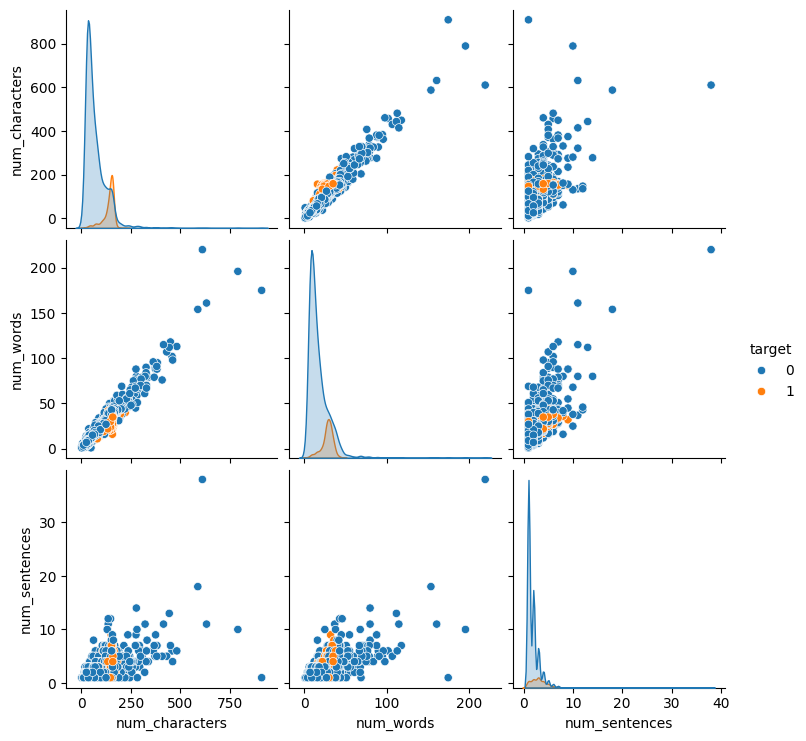

In [53]:
sns.pairplot(df, hue = 'target')

#3. Text Preprocessing
i. Lower Case

ii. Tokenization

iii. Removing special characters

iv. removing stop words and punctuation

v. Stemming

In [76]:
from string import punctuation

In [68]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [63]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [79]:
#making a function that does all the abouve operations in just a function
def transform_all_text(text):
  # lowe case
  text = text.lower()
  # tokenize
  text = nltk.word_tokenize(text)
  # remove special char
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  # removing stopwords and punctiation
  text = y[:] # cloning
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  # stemming

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [81]:
transform_all_text('I am vraj patel and i am currently leaning Machine leaning and my next step would be mlOps and then Deep learning ')

'vraj patel current lean machin lean next step would mlop deep learn'

In [83]:
df['transformed_text'] = df['text'].apply(transform_all_text)

In [84]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


Checking which workds are mostly used in the spam and the ham texts.. by using wordcloud

In [86]:
!pip install wordcloud

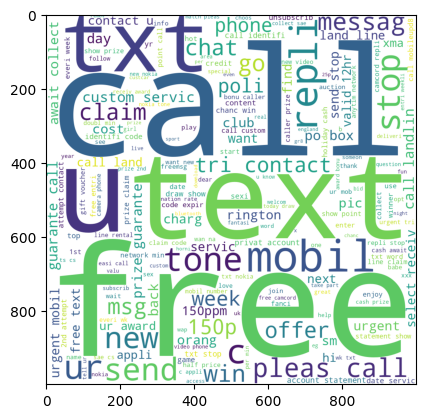

In [98]:
from wordcloud import WordCloud
wc = WordCloud(width=1000, height = 1000, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

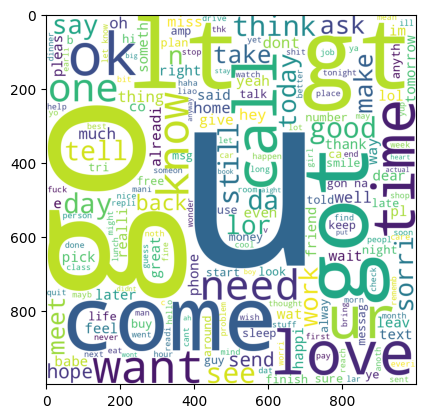

In [99]:
wc = WordCloud(width=1000, height = 1000, min_font_size = 10, background_color = 'white')
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

# Printing all the top 50 words in both spam and ham

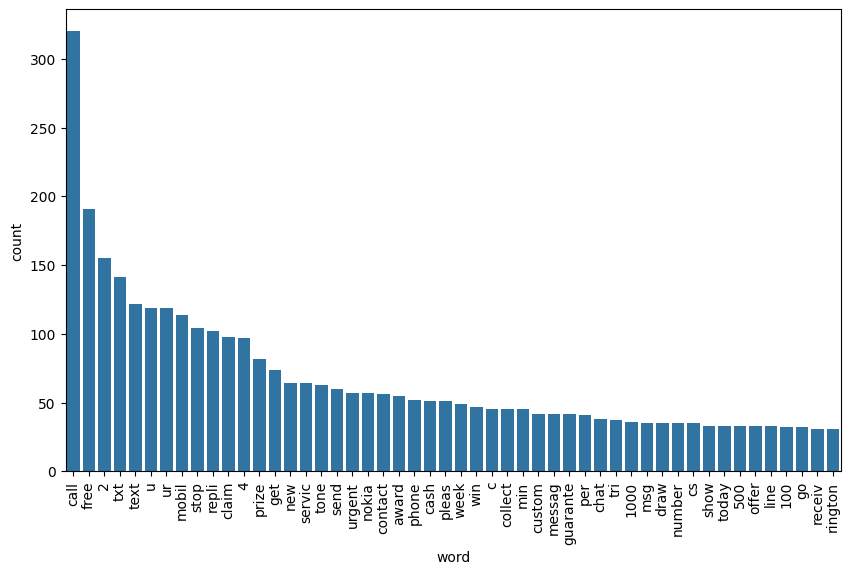

In [102]:
from collections import Counter

# Build the spam_corpus as you did
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

# Get the 50 most common words and their counts
top_words = Counter(spam_corpus).most_common(50)
df_top_words = pd.DataFrame(top_words, columns=['word', 'count'])

# Plot using seaborn
plt.figure(figsize=(10,6))
sns.barplot(data=df_top_words, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

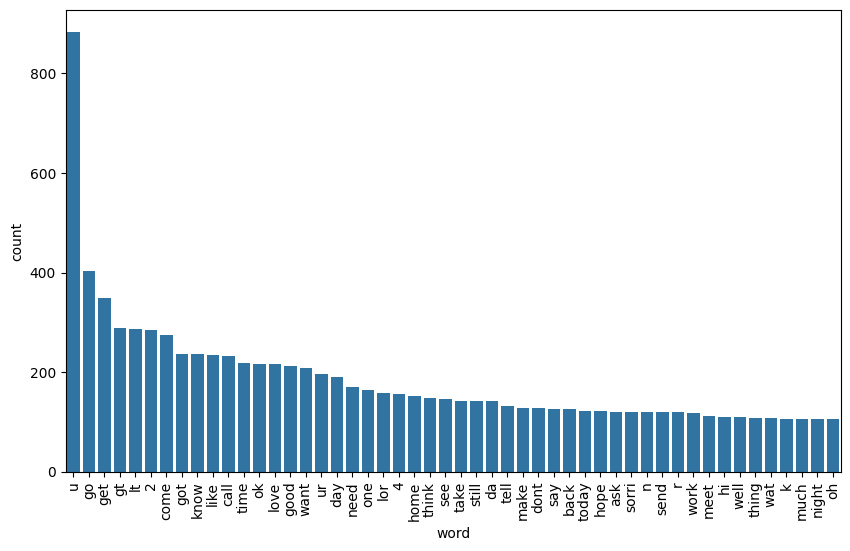

In [105]:
from collections import Counter

# Build the spam_corpus as you did
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

# Get the 50 most common words and their counts
top_words = Counter(ham_corpus).most_common(50)
df_top_words = pd.DataFrame(top_words, columns=['word', 'count'])

# Plot using seaborn
plt.figure(figsize=(10,6))
sns.barplot(data=df_top_words, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

#4. Model Building

Naive Bayes

We will need to vectorize the workds first, for that, there are multiple techniques

1. Bag of words
2. TFidF
3. count vectorizer

In [121]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer

In [107]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [108]:
X.shape

(5168, 6704)

In [109]:
y = df['target'].values

In [111]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [115]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [116]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [118]:
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred_gnb))
print(confusion_matrix(y_test,y_pred_gnb))
print(precision_score(y_test, y_pred_gnb))

0.8800773694390716
[[785 105]
 [ 19 125]]
0.5434782608695652


In [119]:
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred_mnb))
print(confusion_matrix(y_test,y_pred_mnb))
print(precision_score(y_test, y_pred_mnb))

0.971953578336557
[[873  17]
 [ 12 132]]
0.8859060402684564


In [120]:
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred_bnb))
print(confusion_matrix(y_test,y_pred_bnb))
print(precision_score(y_test, y_pred_bnb))

0.9709864603481625
[[887   3]
 [ 27 117]]
0.975


Trying few other ml algorithms.

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [128]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [129]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [130]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [131]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9303675048355899, 0.7465753424657534)

In [132]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9303675048355899
Precision -  0.7465753424657534
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.971953578336557
Precision -  0.8859060402684564
For  DT
Accuracy -  0.9206963249516441
Precision -  0.8974358974358975
For  LR
Accuracy -  0.9671179883945842
Precision -  0.9508196721311475
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9081237911025145
Precision -  0.8888888888888888
For  ETC
Accuracy -  0.9748549323017408
Precision -  1.0
For  GBDT
Accuracy -  0.9429400386847195
Precision -  0.9047619047619048
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.9508196721311475


In [133]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
5,RF,0.971954,1.000000
7,ETC,0.974855,1.000000
9,xgb,0.967118,0.950820
4,LR,0.967118,0.950820
8,GBDT,0.942940,0.904762
3,DT,0.920696,0.897436
6,AdaBoost,0.908124,0.888889
2,NB,0.971954,0.885906
0,SVC,0.930368,0.746575


In [136]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

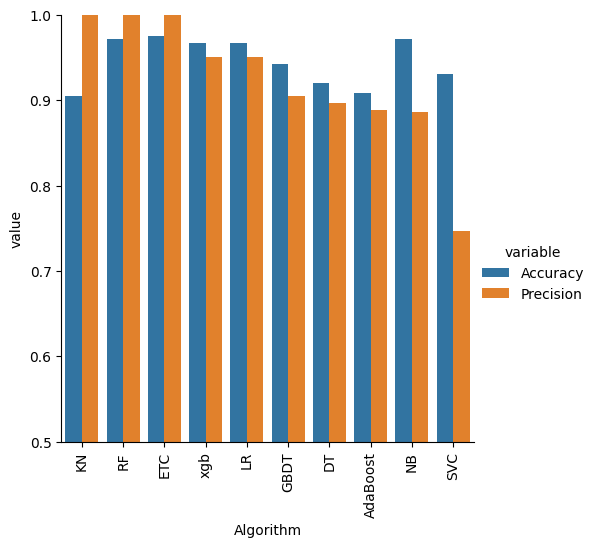

In [137]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [138]:
import pickle

In [139]:
pickle.dump(cv, open('cv.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))